# Learning Style Prediction

Simple supervised learning notebook for predicting `Learning Style`.


In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, log_loss, matthews_corrcoef, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [3]:
TARGET_COLUMN = 'Learning Style'

dataset_candidates = [
    Path('Student_Performance.xlsx'),
    Path('../Student_Performance.xlsx'),
]

for candidate in dataset_candidates:
    if candidate.exists():
        DATASET_PATH = candidate.resolve()
        break
else:
    raise FileNotFoundError('Student_Performance.xlsx not found.')

df = pd.read_excel(DATASET_PATH)
print('Dataset path:', DATASET_PATH)
print('Shape:', df.shape)


Dataset path: C:\Akira\University Stuff\Sem 2\1. AIML\AI Lab\AIML Project\prototype\Student_Performance.xlsx
Shape: (10000, 41)


## Data Check


In [4]:
df.head()


,Student ID,Gender,Age,Grade Level,Attendance Rate,Study Hours,Parental Education Level,Parental Involvement,Extracurricular Activities,Socioeconomic Status,Previous Academic Performance,Class Participation,Health Status,Access to Learning Resources,Internet Access,Learning Style,Teacher-Student Relationship,Peer Influence,Motivation Level,Hours of Sleep,Diet Quality,Transportation Mode,School Type,School Location,Homework Completion Rate,Reading Proficiency,Math Proficiency,Science Proficiency,Language Proficiency,Physical Activity Level,Screen Time,Bullying Incidents,Special Education Services,Counseling Services,Learning Disabilities,Behavioral Issues,Attendance of Tutoring Sessions,School Climate,Parental Employment Status,Household Size,Performance Score
0,1,Male,15,12,80.487800,2.764496,Bachelor's,High,Yes,High,66.661594,Low,Good,No,Yes,Kinesthetic,Positive,Negative,Medium,6.485613,Poor,Bus,Public,Urban,86.568323,99.570689,86.725129,60.785049,90.309659,Low,3.068109,1,No,Yes,Yes,Yes,No,Negative,Unemployed,3,Low
1,2,Female,17,12,96.242678,4.534785,Bachelor's,High,Yes,Low,79.129923,High,Poor,No,No,Visual,Positive,Negative,Medium,5.973091,Poor,Bus,Private,Rural,84.184009,85.818975,66.528350,64.268164,97.812943,Low,1.400854,3,Yes,Yes,No,Yes,No,Negative,Employed,3,Medium
2,3,Male,14,9,84.649681,2.008148,Bachelor's,Medium,Yes,Low,98.070597,High,Poor,Yes,Yes,Visual,Negative,Positive,High,7.740244,Poor,Bus,Private,Rural,76.310262,84.520809,94.547802,86.117803,69.853971,High,3.929084,0,Yes,No,Yes,No,No,Neutral,Employed,3,High
3,4,Male,14,10,86.158599,3.698293,High School,High,No,Low,74.937204,Low,Good,No,Yes,Auditory,Positive,Neutral,Low,7.995529,Average,Bus,Public,Urban,64.108944,97.496243,62.906840,82.763513,96.601016,High,2.789854,3,Yes,No,No,Yes,No,Positive,Employed,4,Medium
4,5,Male,15,10,88.487638,3.408604,Associate,Low,No,Middle,67.129520,Medium,Fair,No,Yes,Kinesthetic,Neutral,Neutral,Medium,8.864511,Average,Car,Private,Rural,84.945985,94.444113,76.347470,84.983862,70.108607,Medium,2.790160,1,Yes,Yes,No,No,No,Positive,Employed,6,Low


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student ID                       10000 non-null  int64  
 1   Gender                           10000 non-null  object 
 2   Age                              10000 non-null  int64  
 3   Grade Level                      10000 non-null  int64  
 4   Attendance Rate                  10000 non-null  float64
 5   Study Hours                      10000 non-null  float64
 6   Parental Education Level         10000 non-null  object 
 7   Parental Involvement             10000 non-null  object 
 8   Extracurricular Activities       10000 non-null  object 
 9   Socioeconomic Status             10000 non-null  object 
 10  Previous Academic Performance    10000 non-null  float64
 11  Class Participation              10000 non-null  object 
 12  Health Status      

In [6]:
missing_summary = df.isna().sum()
missing_summary[missing_summary > 0].sort_values(ascending=False)


Series([], dtype: int64)

In [7]:
df[TARGET_COLUMN].value_counts()


Learning Style
Kinesthetic    3374
Visual         3340
Auditory       3286
Name: count, dtype: int64

## Preprocessing


In [8]:
def normalize(name: str) -> str:
    return ''.join(ch for ch in name.lower() if ch.isalnum())


def clean_categorical(series: pd.Series) -> pd.Series:
    cleaned = series.astype('string').str.strip()
    return cleaned.replace({'': pd.NA, '<NA>': pd.NA, 'nan': pd.NA, 'None': pd.NA, 'null': pd.NA, 'NaN': pd.NA})


id_like_columns = [column for column in df.columns if 'id' in normalize(column)]
drop_columns = sorted(set(id_like_columns + [TARGET_COLUMN]))

X_raw = df.drop(columns=drop_columns).copy()
y = clean_categorical(df[TARGET_COLUMN]).fillna('Unknown')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_columns = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [column for column in X_train_raw.columns if column not in numeric_columns]

for column in numeric_columns:
    train_series = pd.to_numeric(X_train_raw[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
    test_series = pd.to_numeric(X_test_raw[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
    fill_value = float(train_series.median()) if pd.notna(train_series.median()) else 0.0
    X_train_raw[column] = train_series.fillna(fill_value)
    X_test_raw[column] = test_series.fillna(fill_value)

for column in categorical_columns:
    train_series = clean_categorical(X_train_raw[column])
    test_series = clean_categorical(X_test_raw[column])
    mode = train_series.mode(dropna=True)
    fill_value = mode.iloc[0] if not mode.empty else 'Unknown'
    X_train_raw[column] = train_series.fillna(fill_value).astype(str)
    X_test_raw[column] = test_series.fillna(fill_value).astype(str)

X_train = pd.get_dummies(X_train_raw, columns=categorical_columns, dtype=int)
X_test = pd.get_dummies(X_test_raw, columns=categorical_columns, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Numeric columns:', len(numeric_columns))
print('Categorical columns:', len(categorical_columns))
print('Encoded train shape:', X_train.shape)
print('Encoded test shape:', X_test.shape)


Numeric columns: 13
Categorical columns: 25
Encoded train shape: (8000, 79)
Encoded test shape: (2000, 79)


## Train Model


In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)


## Evaluation


In [10]:
def macro_specificity(cm: np.ndarray) -> float:
    values = []
    total = int(cm.sum())
    for i in range(len(cm)):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = total - tp - fn - fp
        denom = tn + fp
        values.append(0.0 if denom == 0 else tn / denom)
    return float(np.mean(values))


labels = sorted(y.unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', labels=model.classes_)

metrics_df = pd.DataFrame([
    {'Metric': 'Accuracy', 'Value': accuracy_score(y_test, y_pred)},
    {'Metric': 'Balanced Accuracy', 'Value': balanced_accuracy_score(y_test, y_pred)},
    {'Metric': 'Precision (Macro)', 'Value': precision_score(y_test, y_pred, average='macro', zero_division=0)},
    {'Metric': 'Recall (Macro)', 'Value': recall_score(y_test, y_pred, average='macro', zero_division=0)},
    {'Metric': 'Specificity (Macro)', 'Value': macro_specificity(cm)},
    {'Metric': 'F1-Score (Macro)', 'Value': f1_score(y_test, y_pred, average='macro', zero_division=0)},
    {'Metric': 'ROC-AUC (OvR)', 'Value': roc_auc},
    {'Metric': 'Log Loss', 'Value': log_loss(y_test, y_prob, labels=model.classes_)},
    {'Metric': 'MCC', 'Value': matthews_corrcoef(y_test, y_pred)},
    {'Metric': 'Cohen Kappa', 'Value': cohen_kappa_score(y_test, y_pred)},
])

metrics_df


,Metric,Value
0,Accuracy,0.330500
1,Balanced Accuracy,0.329948
2,Precision (Macro),0.328714
3,Recall (Macro),0.329948
4,Specificity (Macro),0.665102
5,F1-Score (Macro),0.328526
6,ROC-AUC (OvR),0.521545
7,Log Loss,1.098074
8,MCC,-0.004836
9,Cohen Kappa,-0.004824


In [11]:
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df


,Auditory,Kinesthetic,Visual
Auditory,177,254,226
Kinesthetic,214,265,196
Visual,201,248,219


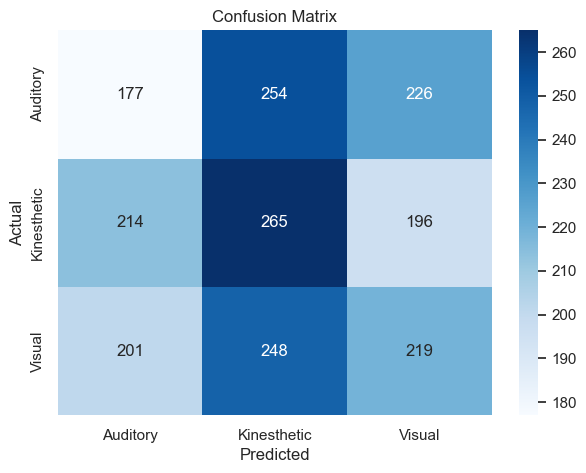

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Sample Prediction


In [13]:
sample_index = 0

sample_raw = X_test_raw.reset_index(drop=True).iloc[[sample_index]]
sample_encoded = X_test.reset_index(drop=True).iloc[[sample_index]]
actual_label = y_test.reset_index(drop=True).iloc[sample_index]
predicted_label = model.predict(sample_encoded)[0]
probabilities = pd.DataFrame({
    'Learning Style': model.classes_,
    'Probability': model.predict_proba(sample_encoded)[0],
}).sort_values('Probability', ascending=False)

print('Original student record:')
display(sample_raw)
print('Actual learning style:', actual_label)
print('Predicted learning style:', predicted_label)
probabilities


Original student record:


,Gender,Age,Grade Level,Attendance Rate,Study Hours,Parental Education Level,Parental Involvement,Extracurricular Activities,Socioeconomic Status,Previous Academic Performance,Class Participation,Health Status,Access to Learning Resources,Internet Access,Teacher-Student Relationship,Peer Influence,Motivation Level,Hours of Sleep,Diet Quality,Transportation Mode,School Type,School Location,Homework Completion Rate,Reading Proficiency,Math Proficiency,Science Proficiency,Language Proficiency,Physical Activity Level,Screen Time,Special Education Services,Counseling Services,Learning Disabilities,Behavioral Issues,Attendance of Tutoring Sessions,School Climate,Parental Employment Status,Household Size,Performance Score
0,Male,14,10,93.00793,2.474043,Bachelor's,Low,No,Middle,89.201937,Low,Poor,Yes,No,Negative,Negative,Low,5.291162,Healthy,Walk,Private,Urban,76.316735,95.548876,72.718437,65.09203,67.023302,Medium,3.406143,No,No,Yes,No,No,Neutral,Employed,2,High


Actual learning style: Visual
Predicted learning style: Visual


,Learning Style,Probability
2,Visual,0.425
1,Kinesthetic,0.290
0,Auditory,0.285


## New Student Prediction


In [14]:
# Copy one row as a template, edit the values, and run this cell.
new_student = X_test_raw.reset_index(drop=True).iloc[[0]].copy()

# Example changes
new_student['Age'] = 16
new_student['Study Hours'] = 5.5
new_student['Attendance Rate'] = 92
new_student['Gender'] = 'Female'
new_student['Parental Involvement'] = 'High'

for column in numeric_columns:
    series = pd.to_numeric(X_train_raw[column], errors='coerce').replace([np.inf, -np.inf], np.nan)
    fill_value = float(series.median()) if pd.notna(series.median()) else 0.0
    new_student[column] = pd.to_numeric(new_student[column], errors='coerce').fillna(fill_value)

for column in categorical_columns:
    train_series = clean_categorical(X_train_raw[column])
    mode = train_series.mode(dropna=True)
    fill_value = mode.iloc[0] if not mode.empty else 'Unknown'
    new_student[column] = clean_categorical(new_student[column]).fillna(fill_value).astype(str)

new_student_encoded = pd.get_dummies(new_student, columns=categorical_columns, dtype=int)
new_student_encoded = new_student_encoded.reindex(columns=X_train.columns, fill_value=0)

new_prediction = model.predict(new_student_encoded)[0]
new_probabilities = pd.DataFrame({
    'Learning Style': model.classes_,
    'Probability': model.predict_proba(new_student_encoded)[0],
}).sort_values('Probability', ascending=False)

print('New student record:')
display(new_student)
print('Predicted learning style:', new_prediction)
new_probabilities


New student record:


,Gender,Age,Grade Level,Attendance Rate,Study Hours,Parental Education Level,Parental Involvement,Extracurricular Activities,Socioeconomic Status,Previous Academic Performance,Class Participation,Health Status,Access to Learning Resources,Internet Access,Teacher-Student Relationship,Peer Influence,Motivation Level,Hours of Sleep,Diet Quality,Transportation Mode,School Type,School Location,Homework Completion Rate,Reading Proficiency,Math Proficiency,Science Proficiency,Language Proficiency,Physical Activity Level,Screen Time,Special Education Services,Counseling Services,Learning Disabilities,Behavioral Issues,Attendance of Tutoring Sessions,School Climate,Parental Employment Status,Household Size,Performance Score
0,Female,16,10,92,5.5,Bachelor's,High,No,Middle,89.201937,Low,Poor,Yes,No,Negative,Negative,Low,5.291162,Healthy,Walk,Private,Urban,76.316735,95.548876,72.718437,65.09203,67.023302,Medium,3.406143,No,No,Yes,No,No,Neutral,Employed,2,High


Predicted learning style: Kinesthetic


,Learning Style,Probability
1,Kinesthetic,0.365
2,Visual,0.335
0,Auditory,0.300
